# Penggabungan dan Pemodelan Kemiskinan Jawa Tengah 2020–2024

Notebook ini disusun untuk proposal skripsi **Perbandingan Multiple Linear Regression dan Random Forest untuk Pemodelan Persentase Penduduk Miskin di Jawa Tengah**.

Alur notebook:

1. Mengunggah enam ZIP data mentah BPS.
2. Membaca lima CSV tahunan di dalam setiap ZIP tanpa mengubah data mentah.
3. Menghapus baris agregat Provinsi Jawa Tengah (`3300`).
4. Menggabungkan data berdasarkan `kode_wilayah` dan `tahun`.
5. Memvalidasi 35 kabupaten/kota × 5 tahun = **175 observasi**.
6. Melakukan EDA hanya pada data latih 2020–2023.
7. Membandingkan Dummy Baseline, Multiple Linear Regression, dan Random Forest pada data uji 2024.
8. Menyajikan interpretasi fitur dan analisis sensitivitas.

**Definisi variabel**

- Target (Y): `persentase_penduduk_miskin`
- Prediktor (X): `uhh`, `hls`, `rls`, `pengeluaran_per_kapita_disesuaikan`, dan `tpt`

> Catatan: garis kemiskinan dan jumlah penduduk miskin tidak dipakai sebagai prediktor karena terlalu dekat dengan target. Hasil model dibaca sebagai hubungan prediktif, bukan hubungan sebab-akibat.


## 1. Import library dan konfigurasi

Di Google Colab, biarkan nilai bawaan. Notebook akan meminta enam ZIP apabila belum ditemukan di `/content`.

Untuk menjalankan di komputer lokal, notebook otomatis memakai `data/raw/` sebagai sumber ZIP, `data/processed/` sebagai dataset hasil gabungan, dan `reports/` sebagai folder keluaran. Keduanya tetap dapat diubah melalui environment variable `SKRIPSI_DATA_DIR` dan `SKRIPSI_OUTPUT_DIR`.


In [1]:
import os
import re
import sys
import zipfile
import warnings
from functools import reduce
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-kemiskinan")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").exists()),
    Path.cwd(),
)
DEFAULT_DATA_DIR = "/content" if IN_COLAB else PROJECT_ROOT / "data" / "raw"
DEFAULT_OUTPUT_DIR = "/content" if IN_COLAB else PROJECT_ROOT / "reports"
PROCESSED_DIR = Path("/content") if IN_COLAB else PROJECT_ROOT / "data" / "processed"

DATA_DIR = Path(os.environ.get("SKRIPSI_DATA_DIR", DEFAULT_DATA_DIR)).resolve()
OUTPUT_DIR = Path(os.environ.get("SKRIPSI_OUTPUT_DIR", DEFAULT_OUTPUT_DIR)).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Folder data   : {DATA_DIR}")
print(f"Folder output : {OUTPUT_DIR}")


Folder data   : D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\data\raw
Folder output : D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports


## 2. Upload enam file ZIP

File yang dibutuhkan:

- `UHH 2020 - 2024.zip`
- `HLS 2020 - 2024.zip`
- `RLS 2020 - 2024.zip`
- `Pengeluaran Per kapita.zip`
- `TPT 2020 - 2024.zip`
- `Kemiskinan 2020 -2024.zip`

Nama file boleh sedikit berbeda selama tetap memuat kata kunci UHH, HLS, RLS, Pengeluaran, TPT, atau Kemiskinan.


In [2]:
available_zip_files = sorted(path.name for path in DATA_DIR.glob("*.zip"))
print(f"ZIP tersedia di {DATA_DIR}:")
for file_name in available_zip_files:
    print(f"- {file_name}")

ZIP tersedia di D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\data\raw:
- HLS 2020 - 2024.zip
- Kemiskinan 2020 -2024.zip
- Pengeluaran Per kapita.zip
- RLS 2020 - 2024.zip
- TPT 2020 - 2024.zip
- UHH 2020 - 2024.zip


In [3]:
ZIP_KEYWORDS = {
    "persentase_penduduk_miskin": "kemiskinan",
    "uhh": "uhh",
    "hls": "hls",
    "rls": "rls",
    "pengeluaran_per_kapita_disesuaikan": "pengeluaran",
    "tpt": "tpt",
}

def find_zip_candidates(folder, keyword):
    return sorted(
        path for path in folder.glob("*.zip")
        if keyword.casefold() in path.name.casefold()
    )

missing_keywords = [
    keyword
    for keyword in ZIP_KEYWORDS.values()
    if not find_zip_candidates(DATA_DIR, keyword)
]

# We check if files are missing; if they aren't, we skip the upload dialog
if missing_keywords and IN_COLAB:
    print("Silakan pilih dan upload keenam ZIP data BPS sekaligus.")
    from google.colab import files
    files.upload()
    missing_keywords = [
        keyword
        for keyword in ZIP_KEYWORDS.values()
        if not find_zip_candidates(DATA_DIR, keyword)
    ]

if missing_keywords:
    raise FileNotFoundError(
        "ZIP belum lengkap. Kata kunci yang belum ditemukan: "
        + ", ".join(missing_keywords)
    )

zip_paths = {}
for variable, keyword in ZIP_KEYWORDS.items():
    candidates = find_zip_candidates(DATA_DIR, keyword)
    if len(candidates) > 1:
        print(f"Peringatan: beberapa ZIP cocok untuk {variable}; menggunakan {candidates[0].name}")
    zip_paths[variable] = candidates[0]

display(pd.DataFrame(
    [{"variabel": key, "file_zip": value.name} for key, value in zip_paths.items()]
))

,variabel,file_zip
0,persentase_penduduk_miskin,Kemiskinan 2020 -2024.zip
1,uhh,UHH 2020 - 2024.zip
2,hls,HLS 2020 - 2024.zip
3,rls,RLS 2020 - 2024.zip
4,pengeluaran_per_kapita_disesuaikan,Pengeluaran Per kapita.zip
5,tpt,TPT 2020 - 2024.zip


## 3. Fungsi pembacaan dan standardisasi

Fungsi berikut membaca CSV langsung dari ZIP. Empat digit pertama pada kolom wilayah dipakai sebagai `kode_wilayah`. Tahun diambil dari nama CSV. Untuk ZIP kemiskinan, kolom terakhir diverifikasi sebagai **Persentase Penduduk Miskin**.


In [4]:
EXPECTED_YEARS = [2020, 2021, 2022, 2023, 2024]


def extract_year(file_name):
    years = re.findall(r"\b(20(?:20|21|22|23|24))\b", Path(file_name).stem)
    if not years:
        raise ValueError(f"Tahun 2020–2024 tidak ditemukan pada nama file: {file_name}")
    return int(years[-1])


def to_numeric_bps(series):
    cleaned = (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "-": np.nan, "...": np.nan, "nan": np.nan})
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def read_indicator_zip(zip_path, variable_name):
    yearly_frames = []

    with zipfile.ZipFile(zip_path) as archive:
        csv_members = sorted(
            name for name in archive.namelist()
            if name.lower().endswith(".csv") and not name.startswith("__MACOSX/")
        )

        if len(csv_members) != 5:
            raise ValueError(
                f"{zip_path.name} seharusnya berisi 5 CSV tahunan, tetapi ditemukan {len(csv_members)}."
            )

        for member in csv_members:
            year = extract_year(member)
            with archive.open(member) as stream:
                raw = pd.read_csv(
                    stream,
                    header=None,
                    dtype=str,
                    encoding="utf-8-sig",
                )

            first_column = raw.iloc[:, 0].fillna("").astype(str).str.strip()
            data_mask = first_column.str.match(r"^33\d{2}\b")
            if not data_mask.any():
                raise ValueError(f"Baris wilayah tidak ditemukan pada {member}")

            first_data_index = raw.index[data_mask][0]
            header_blob = " ".join(
                raw.loc[: first_data_index - 1]
                .fillna("")
                .astype(str)
                .to_numpy()
                .ravel()
            ).casefold()

            if variable_name == "persentase_penduduk_miskin":
                if "persentase penduduk miskin" not in header_blob:
                    raise ValueError(
                        f"Kolom Persentase Penduduk Miskin tidak terverifikasi pada {member}."
                    )

            data = raw.loc[data_mask].copy()
            location = data.iloc[:, 0].astype(str).str.strip()
            code = location.str.extract(r"^(33\d{2})\b", expand=False)
            region = location.str.replace(r"^33\d{2}\s*", "", regex=True).str.strip()
            value = to_numeric_bps(data.iloc[:, -1])

            frame = pd.DataFrame(
                {
                    "kode_wilayah": code.to_numpy(),
                    "kabupaten_kota": region.to_numpy(),
                    "tahun": year,
                    variable_name: value.to_numpy(),
                }
            )

            # 3300 adalah agregat provinsi, bukan salah satu dari 35 kabupaten/kota.
            frame = frame.loc[frame["kode_wilayah"] != "3300"].copy()

            if len(frame) != 35:
                raise ValueError(
                    f"{member}: setelah menghapus agregat provinsi, jumlah baris {len(frame)}, bukan 35."
                )
            yearly_frames.append(frame)

    result = pd.concat(yearly_frames, ignore_index=True)
    result = result.sort_values(["tahun", "kode_wilayah"]).reset_index(drop=True)

    found_years = sorted(result["tahun"].unique().tolist())
    if found_years != EXPECTED_YEARS:
        raise ValueError(f"Tahun pada {zip_path.name} tidak lengkap: {found_years}")
    if result.duplicated(["kode_wilayah", "tahun"]).any():
        raise ValueError(f"Terdapat duplikasi wilayah–tahun pada {zip_path.name}")

    return result


## 4. Membaca semua ZIP dan mengaudit setiap variabel


In [5]:
data_per_variable = {
    variable: read_indicator_zip(path, variable)
    for variable, path in zip_paths.items()
}

source_audit = []
for variable, frame in data_per_variable.items():
    source_audit.append(
        {
            "variabel": variable,
            "baris": len(frame),
            "kabupaten_kota": frame["kode_wilayah"].nunique(),
            "tahun_awal": int(frame["tahun"].min()),
            "tahun_akhir": int(frame["tahun"].max()),
            "duplikat_wilayah_tahun": int(frame.duplicated(["kode_wilayah", "tahun"]).sum()),
            "nilai_kosong": int(frame[variable].isna().sum()),
        }
    )

source_audit = pd.DataFrame(source_audit)
display(source_audit)

assert source_audit["baris"].eq(175).all(), "Ada sumber yang tidak memiliki 175 baris."
assert source_audit["kabupaten_kota"].eq(35).all(), "Ada sumber yang tidak memiliki 35 wilayah."
assert source_audit["duplikat_wilayah_tahun"].eq(0).all(), "Duplikasi ditemukan."
assert source_audit["nilai_kosong"].eq(0).all(), "Nilai kosong ditemukan pada data mentah."

print("Audit enam sumber berhasil.")


,variabel,baris,kabupaten_kota,tahun_awal,tahun_akhir,duplikat_wilayah_tahun,nilai_kosong
0,persentase_penduduk_miskin,175,35,2020,2024,0,0
1,uhh,175,35,2020,2024,0,0
2,hls,175,35,2020,2024,0,0
3,rls,175,35,2020,2024,0,0
4,pengeluaran_per_kapita_disesuaikan,175,35,2020,2024,0,0
5,tpt,175,35,2020,2024,0,0


Audit enam sumber berhasil.


## 5. Menggabungkan enam variabel

Dataset kemiskinan menjadi tabel dasar karena menyediakan target. Lima prediktor digabungkan dengan validasi relasi satu-ke-satu berdasarkan `kode_wilayah` dan `tahun`.


In [6]:
TARGET = "persentase_penduduk_miskin"
FEATURES = [
    "uhh",
    "hls",
    "rls",
    "pengeluaran_per_kapita_disesuaikan",
    "tpt",
]
KEYS = ["kode_wilayah", "tahun"]

master = data_per_variable[TARGET][KEYS + ["kabupaten_kota", TARGET]].copy()
for feature in FEATURES:
    master = master.merge(
        data_per_variable[feature][KEYS + [feature]],
        on=KEYS,
        how="outer",
        validate="one_to_one",
    )

master = master[
    ["kode_wilayah", "kabupaten_kota", "tahun", TARGET] + FEATURES
].sort_values(["kode_wilayah", "tahun"]).reset_index(drop=True)

duplicates = int(master.duplicated(KEYS).sum())
missing_by_column = master.isna().sum()
rows_per_year = master.groupby("tahun").size()

assert len(master) == 175, f"Jumlah observasi {len(master)}, seharusnya 175."
assert master["kode_wilayah"].nunique() == 35, "Jumlah kabupaten/kota bukan 35."
assert sorted(master["tahun"].unique().tolist()) == EXPECTED_YEARS
assert duplicates == 0, "Masih terdapat duplikasi wilayah–tahun."
assert missing_by_column.sum() == 0, "Masih terdapat nilai kosong setelah penggabungan."
assert rows_per_year.eq(35).all(), "Setiap tahun seharusnya memiliki 35 baris."

quality_summary = pd.DataFrame(
    {
        "pemeriksaan": [
            "Jumlah observasi",
            "Jumlah kabupaten/kota",
            "Rentang tahun",
            "Duplikasi wilayah–tahun",
            "Total nilai kosong",
        ],
        "hasil": [
            len(master),
            master["kode_wilayah"].nunique(),
            f"{master['tahun'].min()}–{master['tahun'].max()}",
            duplicates,
            int(missing_by_column.sum()),
        ],
        "status": ["OK"] * 5,
    }
)
display(quality_summary)

MASTER_PATH = PROCESSED_DIR / "kemiskinan_jateng_2020_2024.csv"
master.to_csv(MASTER_PATH, index=False, encoding="utf-8-sig")
print(f"Dataset gabungan tersimpan: {MASTER_PATH}")
display(master.head(10))


,pemeriksaan,hasil,status
0,Jumlah observasi,175,OK
1,Jumlah kabupaten/kota,35,OK
2,Rentang tahun,2020–2024,OK
3,Duplikasi wilayah–tahun,0,OK
4,Total nilai kosong,0,OK


Dataset gabungan tersimpan: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\data\processed\kemiskinan_jateng_2020_2024.csv


,kode_wilayah,kabupaten_kota,tahun,persentase_penduduk_miskin,uhh,hls,rls,pengeluaran_per_kapita_disesuaikan,tpt
0,3301,Kabupaten Cilacap,2020,11.46,74.28,12.50,6.97,10440,9.10
1,3301,Kabupaten Cilacap,2021,11.67,74.45,12.63,7.09,10534,9.97
2,3301,Kabupaten Cilacap,2022,11.02,74.59,12.66,7.18,10904,9.62
3,3301,Kabupaten Cilacap,2023,10.99,74.73,12.67,7.39,11432,8.74
4,3301,Kabupaten Cilacap,2024,10.68,74.97,12.69,7.40,11868,7.83
5,3302,Kabupaten Banyumas,2020,13.26,74.05,12.85,7.52,11448,6.00
6,3302,Kabupaten Banyumas,2021,13.66,74.13,13.03,7.63,11546,6.05
7,3302,Kabupaten Banyumas,2022,12.84,74.16,13.21,7.78,11905,6.05
8,3302,Kabupaten Banyumas,2023,12.53,74.20,13.26,7.87,12492,6.35
9,3302,Kabupaten Banyumas,2024,11.95,74.34,13.34,7.91,12960,6.18


## 6. Exploratory Data Analysis (EDA)

Statistik, korelasi, dan VIF berikut dihitung menggunakan **data latih 2020–2023 saja**. Data tahun 2024 tetap dikunci sebagai data uji akhir.


Observasi EDA/data latih: 140


,count,mean,std,min,25%,50%,75%,max
persentase_penduduk_miskin,140.0,10.846,3.393,4.23,7.908,10.595,12.898,17.83
uhh,140.0,75.392,1.304,73.44,74.395,74.920,76.337,77.93
hls,140.0,12.989,0.919,11.46,12.438,12.850,13.340,15.55
rls,140.0,8.066,1.250,6.21,7.240,7.755,8.735,11.24
pengeluaran_per_kapita_disesuaikan,140.0,11428.864,1810.761,8461.00,10160.250,11038.000,12452.750,16650.00
tpt,140.0,5.622,1.941,1.76,4.288,5.325,6.703,9.97


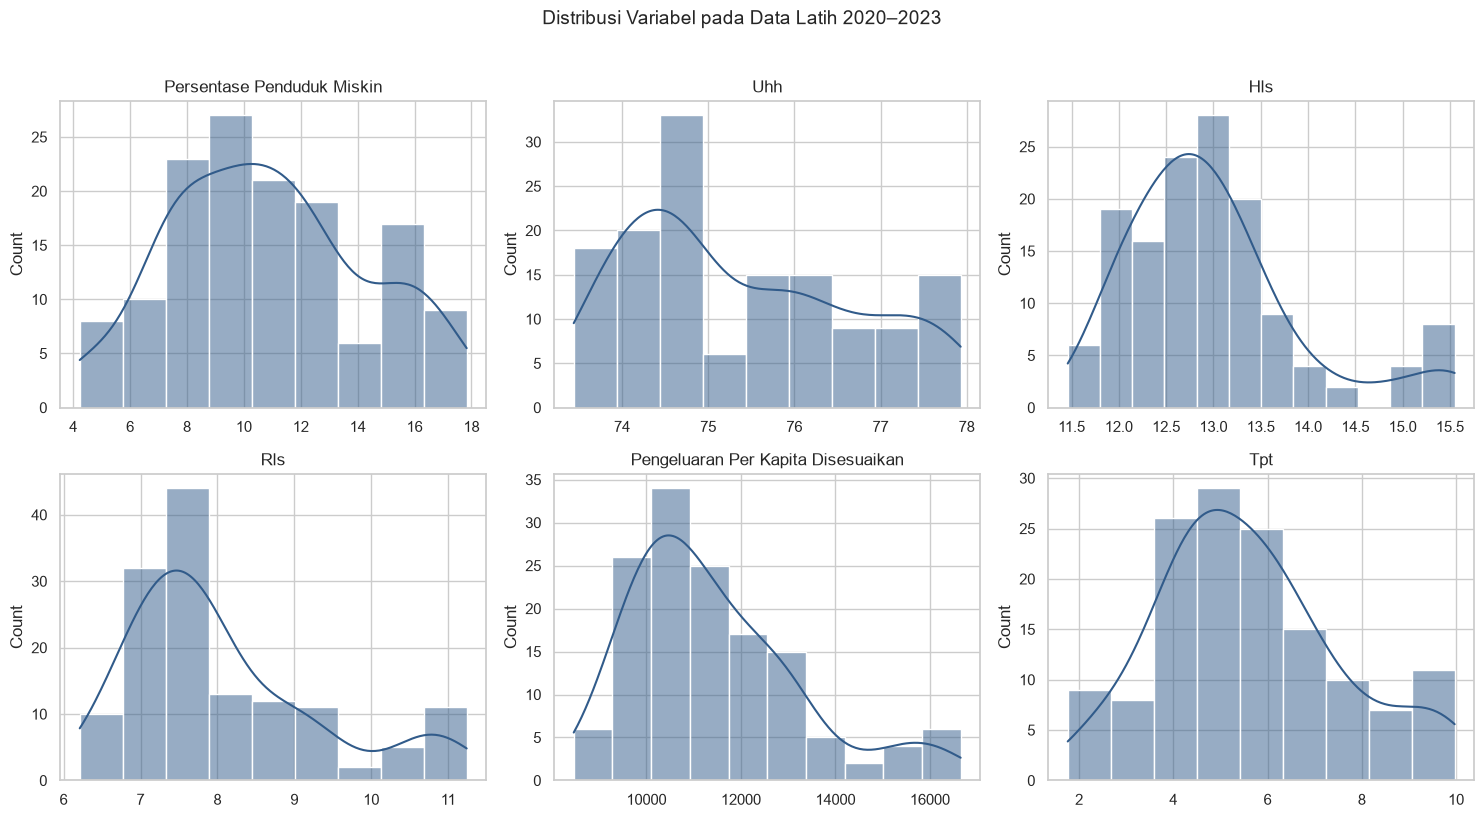

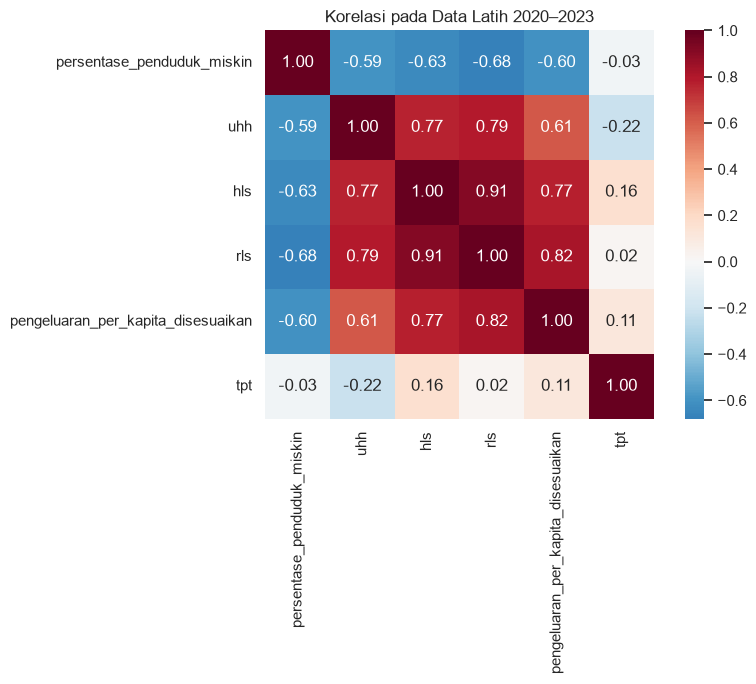

In [7]:
model_columns = [TARGET] + FEATURES
eda_train = master.loc[master["tahun"] <= 2023].copy()

print(f"Observasi EDA/data latih: {len(eda_train)}")
descriptive_statistics = eda_train[model_columns].describe().T.round(3)
display(descriptive_statistics)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, axis in zip(model_columns, axes.ravel()):
    sns.histplot(eda_train[column], kde=True, ax=axis, color="#315b8a")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("")
plt.suptitle("Distribusi Variabel pada Data Latih 2020–2023", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

correlation = eda_train[model_columns].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Korelasi pada Data Latih 2020–2023")
plt.tight_layout()
plt.show()


In [8]:
def calculate_vif(frame):
    rows = []
    for feature in frame.columns:
        other_features = [column for column in frame.columns if column != feature]
        auxiliary_model = LinearRegression().fit(frame[other_features], frame[feature])
        r_squared = auxiliary_model.score(frame[other_features], frame[feature])
        vif = np.inf if np.isclose(1 - r_squared, 0) else 1 / (1 - r_squared)
        rows.append({"fitur": feature, "R2_auxiliary": r_squared, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)


vif_table = calculate_vif(eda_train[FEATURES])
display(vif_table.round(3))
print("VIF di atas 5 perlu ditelaah, bukan otomatis menjadi alasan menghapus fitur.")


,fitur,R2_auxiliary,VIF
0,rls,0.883,8.569
1,hls,0.868,7.551
2,uhh,0.722,3.598
3,pengeluaran_per_kapita_disesuaikan,0.686,3.188
4,tpt,0.328,1.489


VIF di atas 5 perlu ditelaah, bukan otomatis menjadi alasan menghapus fitur.


## 7. Pemisahan temporal

- Data latih: 2020–2023 (140 observasi)
- Data uji akhir: 2024 (35 observasi)

Tidak digunakan pembagian acak karena observasi mempunyai dimensi waktu.


In [9]:
model_data = master.sort_values(["tahun", "kode_wilayah"]).reset_index(drop=True)
train_df = model_data.loc[model_data["tahun"] <= 2023].reset_index(drop=True)
test_df = model_data.loc[model_data["tahun"] == 2024].reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

assert len(train_df) == 140
assert len(test_df) == 35
assert set(train_df["tahun"].unique()) == {2020, 2021, 2022, 2023}
assert set(test_df["tahun"].unique()) == {2024}

print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)


Data latih: (140, 5) | Data uji: (35, 5)


## 8. Baseline, Multiple Linear Regression, dan Random Forest

MAE menjadi metrik utama karena satuannya langsung berupa poin persentase kemiskinan. RMSE dan R² digunakan sebagai metrik pendukung.

Random Forest dituning memakai validasi expanding-year:

- latih 2020 → validasi 2021
- latih 2020–2021 → validasi 2022
- latih 2020–2022 → validasi 2023


In [10]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

mlr = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
mlr.fit(X_train, y_train)

train_year_array = train_df["tahun"].to_numpy()
expanding_year_splits = []
for validation_year in [2021, 2022, 2023]:
    train_indices = np.where(train_year_array < validation_year)[0]
    validation_indices = np.where(train_year_array == validation_year)[0]
    expanding_year_splits.append((train_indices, validation_indices))

rf_parameter_space = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 4, 6, 10, 15],
    "max_features": ["sqrt", 0.6, 1.0],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_parameter_space,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=expanding_year_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print("Parameter Random Forest terbaik:")
display(pd.Series(rf_search.best_params_, name="nilai").to_frame())
print(f"MAE validasi temporal rata-rata terbaik: {-rf_search.best_score_:.4f}")


Parameter Random Forest terbaik:


,nilai
n_estimators,300.0
min_samples_split,2.0
min_samples_leaf,1.0
max_features,0.6
max_depth,15.0


MAE validasi temporal rata-rata terbaik: 1.2016


,Model,MAE,RMSE,R2
0,Random Forest,1.0700,1.3392,0.8210
1,Multiple Linear Regression,1.9047,2.3243,0.4608
2,Dummy Baseline,2.6938,3.2455,-0.0514


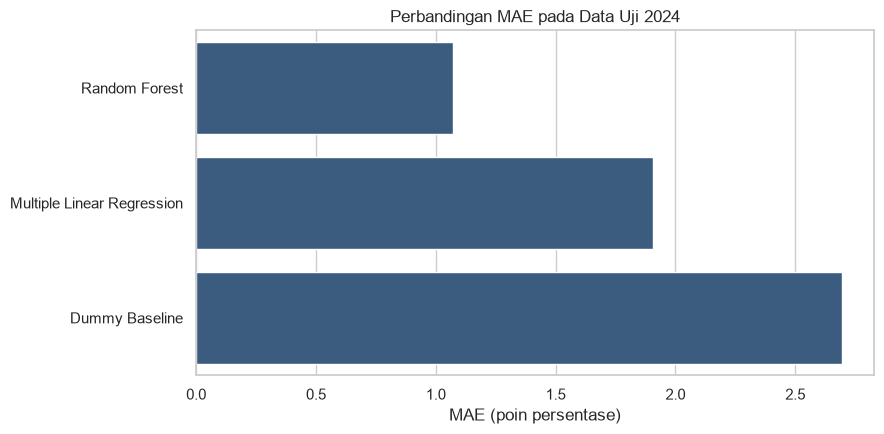

In [11]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


fitted_models = {
    "Dummy Baseline": dummy,
    "Multiple Linear Regression": mlr,
    "Random Forest": rf_best,
}

test_predictions = {}
comparison_rows = []
for model_name, model in fitted_models.items():
    prediction = model.predict(X_test)
    test_predictions[model_name] = prediction
    comparison_rows.append({"Model": model_name, **regression_metrics(y_test, prediction)})

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)
display(model_comparison.round(4))

plt.figure(figsize=(9, 4.5))
sns.barplot(data=model_comparison, x="MAE", y="Model", color="#315b8a")
plt.title("Perbandingan MAE pada Data Uji 2024")
plt.xlabel("MAE (poin persentase)")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 9. Prediksi per kabupaten/kota dan residual


,kode_wilayah,kabupaten_kota,tahun,persentase_penduduk_miskin,prediksi_dummy,prediksi_mlr,prediksi_random_forest,residual_mlr,residual_random_forest,absolute_error_mlr,absolute_error_random_forest
27,3328,Kabupaten Tegal,2024,6.81,10.846,12.205,10.087,-5.395,-3.277,5.395,3.277
25,3326,Kabupaten Pekalongan,2024,8.95,10.846,12.230,11.576,-3.280,-2.626,3.280,2.626
24,3325,Kabupaten Batang,2024,8.73,10.846,12.236,10.986,-3.506,-2.256,3.506,2.256
4,3305,Kabupaten Kebumen,2024,15.71,10.846,11.596,13.667,4.114,2.043,4.114,2.043
9,3310,Kabupaten Klaten,2024,12.04,10.846,8.061,10.099,3.979,1.941,3.979,1.941
21,3322,Kabupaten Semarang,2024,6.96,10.846,10.011,8.897,-3.051,-1.937,3.051,1.937
19,3320,Kabupaten Jepara,2024,6.09,10.846,10.304,7.988,-4.214,-1.898,4.214,1.898
16,3317,Kabupaten Rembang,2024,14.02,10.846,11.545,12.161,2.475,1.859,2.475,1.859
23,3324,Kabupaten Kendal,2024,9.35,10.846,11.148,11.093,-1.798,-1.743,1.798,1.743
3,3304,Kabupaten Banjarnegara,2024,14.71,10.846,12.703,13.032,2.007,1.678,2.007,1.678


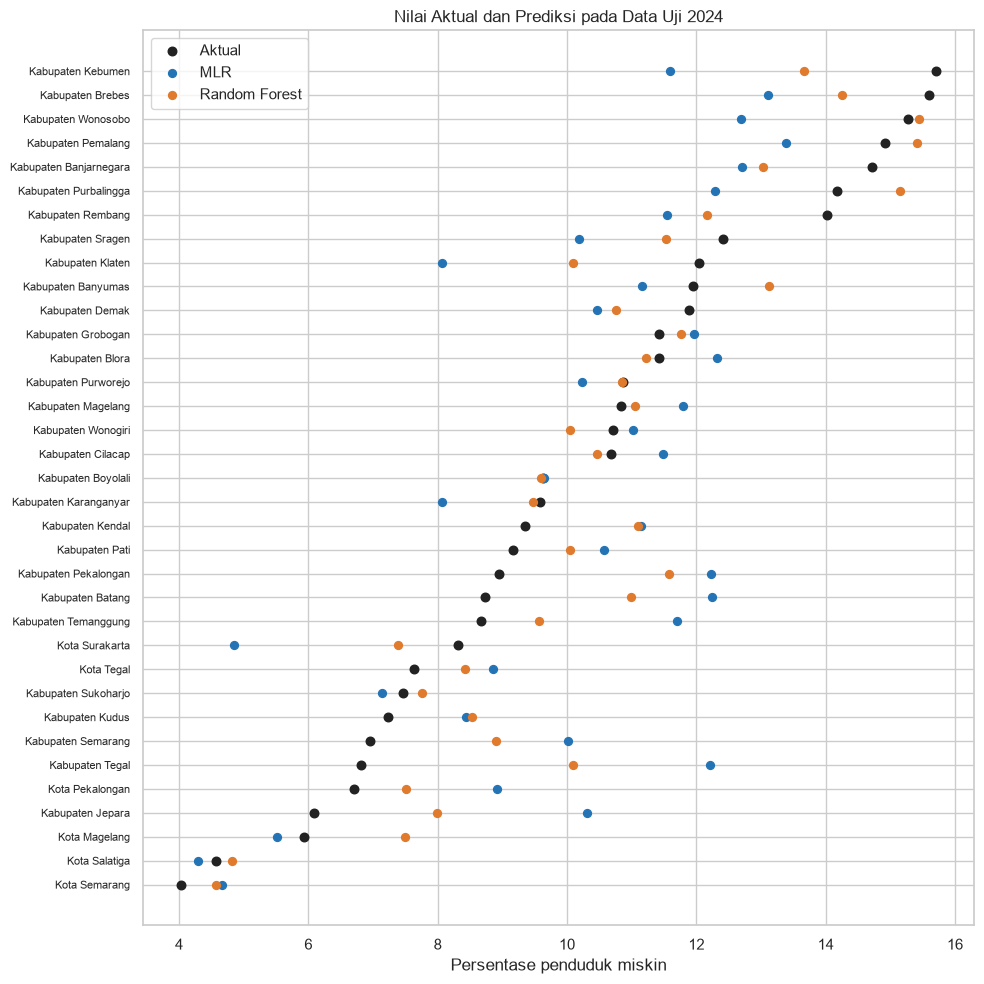

In [12]:
prediction_test = test_df[["kode_wilayah", "kabupaten_kota", "tahun", TARGET]].copy()
prediction_test["prediksi_dummy"] = test_predictions["Dummy Baseline"]
prediction_test["prediksi_mlr"] = test_predictions["Multiple Linear Regression"]
prediction_test["prediksi_random_forest"] = test_predictions["Random Forest"]
prediction_test["residual_mlr"] = prediction_test[TARGET] - prediction_test["prediksi_mlr"]
prediction_test["residual_random_forest"] = (
    prediction_test[TARGET] - prediction_test["prediksi_random_forest"]
)
prediction_test["absolute_error_mlr"] = prediction_test["residual_mlr"].abs()
prediction_test["absolute_error_random_forest"] = prediction_test[
    "residual_random_forest"
].abs()

display(
    prediction_test.sort_values("absolute_error_random_forest", ascending=False)
    .head(10)
    .round(3)
)

plot_data = prediction_test.sort_values(TARGET).reset_index(drop=True)
y_position = np.arange(len(plot_data))
plt.figure(figsize=(10, 10))
plt.scatter(plot_data[TARGET], y_position, label="Aktual", s=38, color="#222222")
plt.scatter(plot_data["prediksi_mlr"], y_position, label="MLR", s=32, color="#2474b5")
plt.scatter(
    plot_data["prediksi_random_forest"],
    y_position,
    label="Random Forest",
    s=32,
    color="#e07a2d",
)
plt.yticks(y_position, plot_data["kabupaten_kota"], fontsize=8)
plt.xlabel("Persentase penduduk miskin")
plt.ylabel("")
plt.title("Nilai Aktual dan Prediksi pada Data Uji 2024")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Interpretasi kontribusi prediktif

- MLR: koefisien prediktor yang telah distandardisasi.
- Random Forest: permutation importance pada data uji 2024.

Besaran berikut tidak boleh ditafsirkan sebagai efek kausal.


,fitur,koefisien_terstandar
0,rls,-1.4507
1,uhh,-0.6890
2,pengeluaran_per_kapita_disesuaikan,-0.4784
3,tpt,-0.1890
4,hls,0.1019


,fitur,importance_mean,importance_std
0,rls,1.3637,0.1816
1,hls,0.9345,0.1305
2,uhh,0.2381,0.0549
3,pengeluaran_per_kapita_disesuaikan,0.1786,0.0455
4,tpt,0.1053,0.0329


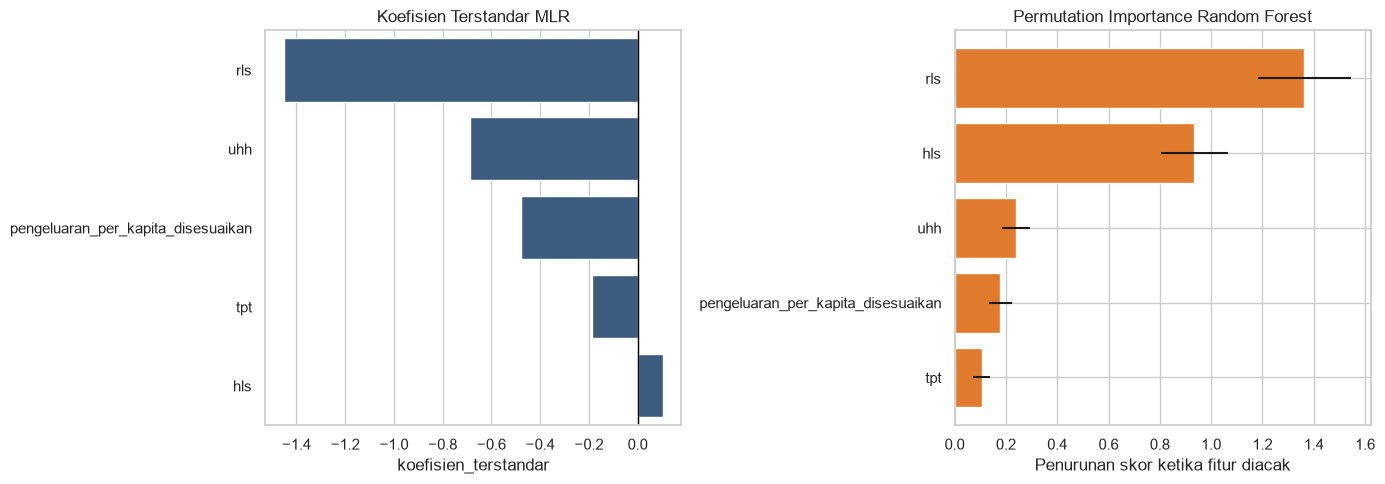

In [13]:
standardized_coefficients = (
    pd.DataFrame(
        {
            "fitur": FEATURES,
            "koefisien_terstandar": mlr.named_steps["model"].coef_,
        }
    )
    .assign(absolut=lambda frame: frame["koefisien_terstandar"].abs())
    .sort_values("absolut", ascending=False)
    .reset_index(drop=True)
)

rf_permutation = permutation_importance(
    rf_best,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
permutation_table = (
    pd.DataFrame(
        {
            "fitur": FEATURES,
            "importance_mean": rf_permutation.importances_mean,
            "importance_std": rf_permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(standardized_coefficients.drop(columns="absolut").round(4))
display(permutation_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=standardized_coefficients,
    x="koefisien_terstandar",
    y="fitur",
    color="#315b8a",
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Koefisien Terstandar MLR")
axes[0].set_ylabel("")

axes[1].barh(
    permutation_table["fitur"],
    permutation_table["importance_mean"],
    xerr=permutation_table["importance_std"],
    color="#e07a2d",
)
axes[1].invert_yaxis()
axes[1].set_title("Permutation Importance Random Forest")
axes[1].set_xlabel("Penurunan skor ketika fitur diacak")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


## 11. Diagnostik residual Multiple Linear Regression

Diagnostik dilakukan pada residual data latih. Uji Shapiro–Wilk hanya menjadi informasi pendukung; keputusan utama penelitian tetap berdasarkan performa prediksi pada data uji 2024.


Shapiro–Wilk W = 0.9800; p-value = 0.0378


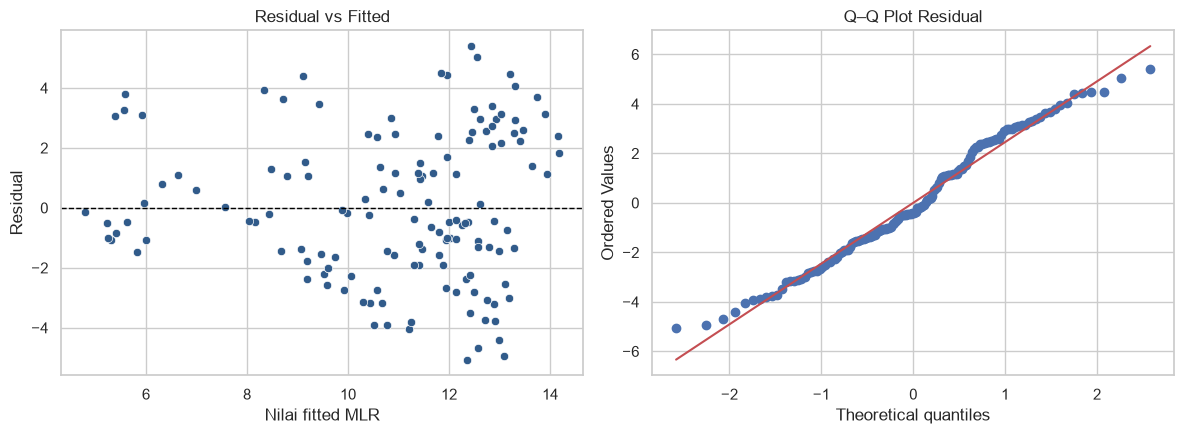

In [14]:
train_fitted_mlr = mlr.predict(X_train)
train_residual_mlr = y_train.to_numpy() - train_fitted_mlr

shapiro_statistic, shapiro_pvalue = stats.shapiro(train_residual_mlr)
print(f"Shapiro–Wilk W = {shapiro_statistic:.4f}; p-value = {shapiro_pvalue:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(x=train_fitted_mlr, y=train_residual_mlr, ax=axes[0], color="#315b8a")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Nilai fitted MLR")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Fitted")

stats.probplot(train_residual_mlr, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q Plot Residual")
plt.tight_layout()
plt.show()


## 12. Analisis sensitivitas

Sesuai rancangan proposal, model utama dibandingkan dengan:

1. Model tanpa HLS, untuk menelaah korelasi tinggi HLS–RLS.
2. Model tanpa pengeluaran per kapita yang disesuaikan, untuk menelaah kedekatan konseptualnya dengan kemiskinan.

Random Forest pada setiap varian menggunakan parameter terbaik hasil tuning model utama, kemudian dilatih ulang pada fitur varian tersebut.


,Varian,Model,Jumlah fitur,MAE,RMSE,R2
0,Model utama,Multiple Linear Regression,5,1.9047,2.3243,0.4608
1,Model utama,Random Forest,5,1.0700,1.3392,0.8210
2,Tanpa HLS,Multiple Linear Regression,4,1.9061,2.3239,0.4610
3,Tanpa HLS,Random Forest,4,1.4842,1.7772,0.6847
4,Tanpa pengeluaran per kapita,Multiple Linear Regression,4,1.9684,2.3586,0.4447
5,Tanpa pengeluaran per kapita,Random Forest,4,1.0623,1.3315,0.8230


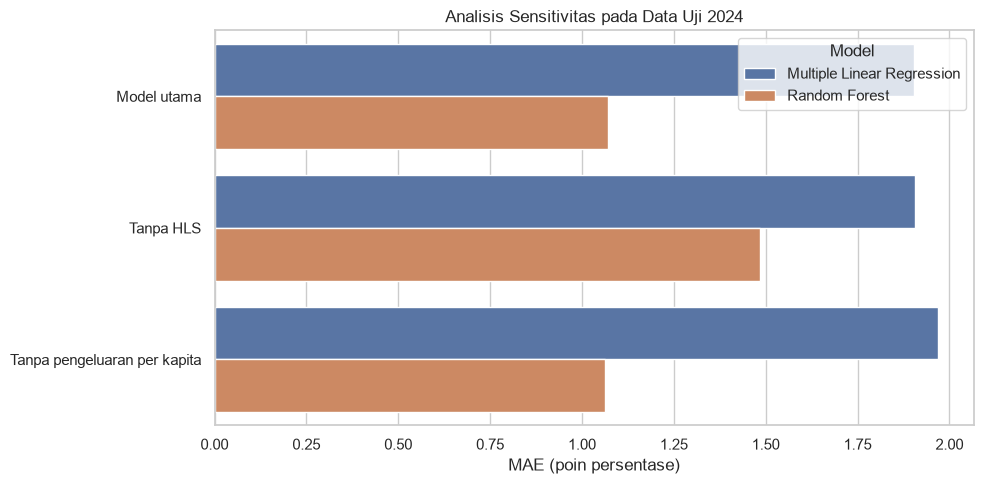

In [15]:
sensitivity_variants = {
    "Model utama": FEATURES,
    "Tanpa HLS": [feature for feature in FEATURES if feature != "hls"],
    "Tanpa pengeluaran per kapita": [
        feature
        for feature in FEATURES
        if feature != "pengeluaran_per_kapita_disesuaikan"
    ],
}

sensitivity_rows = []
for variant_name, variant_features in sensitivity_variants.items():
    mlr_variant = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )
    rf_variant = clone(rf_best)

    for model_name, model in {
        "Multiple Linear Regression": mlr_variant,
        "Random Forest": rf_variant,
    }.items():
        model.fit(train_df[variant_features], y_train)
        prediction = model.predict(test_df[variant_features])
        sensitivity_rows.append(
            {
                "Varian": variant_name,
                "Model": model_name,
                "Jumlah fitur": len(variant_features),
                **regression_metrics(y_test, prediction),
            }
        )

sensitivity_results = pd.DataFrame(sensitivity_rows)
display(sensitivity_results.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=sensitivity_results, x="MAE", y="Varian", hue="Model")
plt.title("Analisis Sensitivitas pada Data Uji 2024")
plt.xlabel("MAE (poin persentase)")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 13. Menyimpan seluruh hasil

File CSV di bawah dapat digunakan untuk penulisan Bab IV. Jangan mengubah file mentah; lakukan perbaikan melalui kode lalu jalankan ulang notebook.


In [16]:
output_files = {
    "dataset_gabungan": MASTER_PATH,
    "perbandingan_model": OUTPUT_DIR / "hasil_perbandingan_model.csv",
    "prediksi_2024": OUTPUT_DIR / "prediksi_kemiskinan_2024.csv",
    "koefisien_mlr": OUTPUT_DIR / "koefisien_terstandar_mlr.csv",
    "permutation_importance_rf": OUTPUT_DIR / "permutation_importance_random_forest.csv",
    "analisis_sensitivitas": OUTPUT_DIR / "hasil_analisis_sensitivitas.csv",
    "audit_sumber": OUTPUT_DIR / "audit_sumber_data.csv",
}

model_comparison.to_csv(output_files["perbandingan_model"], index=False, encoding="utf-8-sig")
prediction_test.to_csv(output_files["prediksi_2024"], index=False, encoding="utf-8-sig")
standardized_coefficients.drop(columns="absolut").to_csv(
    output_files["koefisien_mlr"], index=False, encoding="utf-8-sig"
)
permutation_table.to_csv(
    output_files["permutation_importance_rf"], index=False, encoding="utf-8-sig"
)
sensitivity_results.to_csv(
    output_files["analisis_sensitivitas"], index=False, encoding="utf-8-sig"
)
source_audit.to_csv(output_files["audit_sumber"], index=False, encoding="utf-8-sig")

print("File hasil:")
for label, path in output_files.items():
    print(f"- {label}: {path}")

DOWNLOAD_MASTER_DATASET = False
if DOWNLOAD_MASTER_DATASET and IN_COLAB:
    from google.colab import files
    files.download(str(MASTER_PATH))


File hasil:
- dataset_gabungan: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\data\processed\kemiskinan_jateng_2020_2024.csv
- perbandingan_model: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\hasil_perbandingan_model.csv
- prediksi_2024: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\prediksi_kemiskinan_2024.csv
- koefisien_mlr: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\koefisien_terstandar_mlr.csv
- permutation_importance_rf: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\permutation_importance_random_forest.csv
- analisis_sensitivitas: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\hasil_analisis_sensitivitas.csv
- audit_sumber: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\audit_sumber_data.csv


In [17]:
import zipfile

# Define the name for the output ZIP file
zip_filename = "hasil_analisis_skripsi.zip"
zip_path = OUTPUT_DIR / zip_filename

# Create a ZIP file containing all generated CSVs
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for label, path in output_files.items():
        if path.exists():
            zipf.write(path, arcname=path.name)

print(f"ZIP file created at: {zip_path}")

# Automatically trigger download in Colab
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

ZIP file created at: D:\Metopen\Kemiskinan Jawa Tengah 2020 - 2024\reports\hasil_analisis_skripsi.zip


## Catatan pelaporan skripsi

- Laporkan bahwa data akhir memiliki 175 observasi tanpa missing value dan duplikasi.
- Nyatakan secara eksplisit bahwa 2024 tidak digunakan untuk EDA penentuan model maupun tuning, melainkan sebagai data uji akhir untuk perbandingan yang telah ditetapkan sebelumnya.
- Bandingkan setiap model dengan Dummy Baseline, bukan hanya MLR melawan Random Forest.
- Utamakan MAE; gunakan RMSE dan R² sebagai pendukung.
- Jelaskan tanda dan besar koefisien MLR serta permutation importance sebagai kontribusi prediktif, bukan sebab-akibat.
- Bahas hasil model sensitivitas ketika HLS atau pengeluaran per kapita dikeluarkan.
